In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

In [2]:
power = pd.read_excel("/content/PGCB_date_power_demand.xlsx")
weather = pd.read_excel("/content/weather_data.xlsx", header=2)
econ = pd.read_csv("/content/economic_full_1.csv")

print("Power data shape:", power.shape)
print("Weather data shape:", weather.shape)
print("Economic data shape:", econ.shape)

Power data shape: (92650, 15)
Weather data shape: (107305, 10)
Economic data shape: (1516, 69)


In [3]:
print("POWER DATA")
power.head()

print("WEATHER DATA")
weather.head()

print("ECONOMIC DATA")
econ.head()

POWER DATA
WEATHER DATA
ECONOMIC DATA


,Country Name,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,X,"Intentional homicides, male (per 100,000 male)",VC.IHR.PSRC.MA.P5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,X,Battle-related deaths (number of people),VC.BTL.DETH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,41.000000,47.000000,NaN,NaN,2.000000,NaN,2.000000,NaN,2.000000,NaN
2,X,Voice and Accountability: Percentile Rank,VA.PER.RNK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.541872,30.049261,27.184465,26.570047,26.570047,28.019323,28.019323,27.450981,NaN,NaN
3,X,Transport services (% of commercial service ex...,TX.VAL.TRAN.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,20.820301,21.484188,22.048898,19.559759,22.257010,27.162699,25.520411,17.176637,23.495141,NaN
4,X,"Computer, communications and other services (%...",TX.VAL.OTHR.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,64.068305,57.202109,62.313903,63.578283,67.395621,64.565856,63.537174,67.817057,65.566600,NaN


In [4]:
# converting datetime column properly
power["datetime"] = pd.to_datetime(power["datetime"])

# sorting by time
power = power.sort_values("datetime")

power.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
24,2015-04-19 00:00:00,4821.0,4821,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
22,2015-04-19 01:00:00,3612.0,3612,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
21,2015-04-19 02:00:00,3727.0,3727,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
20,2015-04-19 03:00:00,3632.0,3632,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
19,2015-04-19 04:00:00,3641.0,3641,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN


In [5]:
# extracting useful time features
power["hour"] = power["datetime"].dt.hour
power["dayofweek"] = power["datetime"].dt.dayofweek
power["month"] = power["datetime"].dt.month

power[["datetime", "hour", "dayofweek", "month"]].head()

,datetime,hour,dayofweek,month
24,2015-04-19 00:00:00,0,6,4
22,2015-04-19 01:00:00,1,6,4
21,2015-04-19 02:00:00,2,6,4
20,2015-04-19 03:00:00,3,6,4
19,2015-04-19 04:00:00,4,6,4


In [6]:
# previous demand values
power["lag_1"] = power["demand_mw"].shift(1)
power["lag_24"] = power["demand_mw"].shift(24)

power[["demand_mw", "lag_1", "lag_24"]].head(30)

,demand_mw,lag_1,lag_24
24,4821,NaN,NaN
22,3612,4821.0,NaN
21,3727,3612.0,NaN
20,3632,3727.0,NaN
19,3641,3632.0,NaN
18,3283,3641.0,NaN
17,3444,3283.0,NaN
16,3592,3444.0,NaN
15,4049,3592.0,NaN
14,4488,4049.0,NaN


In [7]:
power["rolling_mean_24"] = (
    power["demand_mw"]
    .shift(1)
    .rolling(24)
    .mean()
)

power[["demand_mw", "rolling_mean_24"]].head(30)

,demand_mw,rolling_mean_24
24,4821,NaN
22,3612,NaN
21,3727,NaN
20,3632,NaN
19,3641,NaN
18,3283,NaN
17,3444,NaN
16,3592,NaN
15,4049,NaN
14,4488,NaN


In [8]:
df_model = power[
    ["demand_mw", "hour", "dayofweek", "month",
     "lag_1", "lag_24", "rolling_mean_24"]
].dropna()

print(df_model.shape)
df_model.head()

(92626, 7)


,demand_mw,hour,dayofweek,month,lag_1,lag_24,rolling_mean_24
0,6323,22,6,4,6667.0,4821.0,5073.208333
35,5678,0,0,4,6323.0,3612.0,5135.791667
33,5183,7,0,4,5678.0,3727.0,5221.875000
34,5569,8,0,4,5183.0,3632.0,5282.541667
32,5603,9,0,4,5569.0,3641.0,5363.250000


In [9]:
# keeping chronological order
split_point = int(len(df_model) * 0.8)

train = df_model.iloc[:split_point]
test = df_model.iloc[split_point:]

X_train = train.drop("demand_mw", axis=1)
y_train = train["demand_mw"]

X_test = test.drop("demand_mw", axis=1)
y_test = test["demand_mw"]

print(X_train.shape, X_test.shape)

(74100, 6) (18526, 6)


In [10]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [11]:
y_pred = rf_model.predict(X_test)

mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print("Final Test MAPE (%):", round(mape, 2))

Final Test MAPE (%): 6.04


lag_1              0.876166
lag_24             0.060522
rolling_mean_24    0.029257
hour               0.020010
month              0.007804
dayofweek          0.006242
dtype: float64


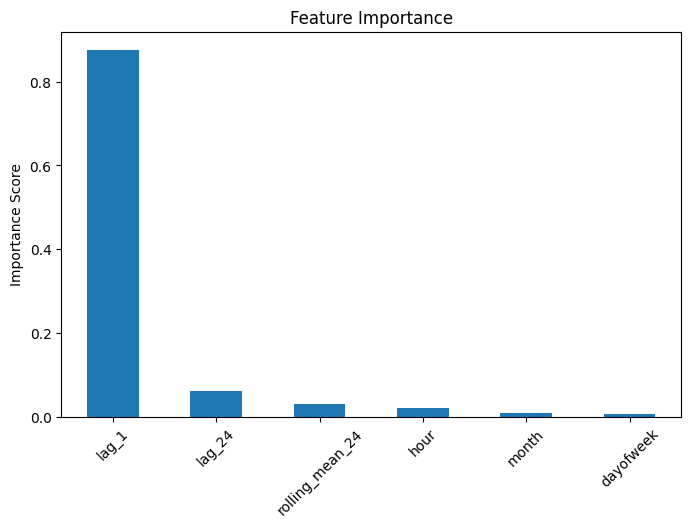

In [12]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(ascending=False)

print(importance)

plt.figure(figsize=(8,5))
importance.plot(kind="bar")
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.show()

In [13]:
print("The model performs reasonably well.")
print("Previous hour demand seems to be the most important feature.")
print("Daily repeating patterns are also captured through lag_24.")

The model performs reasonably well.
Previous hour demand seems to be the most important feature.
Daily repeating patterns are also captured through lag_24.


## Final Analysis and Interpretation

The Random Forest model gave a final MAPE of 6.04%, which I think is a good result for predicting the next hour’s electricity demand.

The most important feature was `lag_1`, meaning the previous hour’s demand. This makes sense because electricity demand usually changes gradually.

`lag_24` was also important, which shows that similar patterns repeat at the same hour each day.

The rolling mean helped capture the recent trend in demand.

Overall, the model mainly depends on recent past demand and daily repeating patterns.